In [1]:
using Pkg, Plots
Pkg.activate("..")
Pkg.instantiate()
using Clapeyron, cDFT

  Activating project at `/nfs/zeal_nas/home_mount/pwalker/Projects/cDFT.jl`


## General set-up
The cDFT and Clapeyron packages are very closely related. Clapeyron provides all the bulk information while cDFT handles all inhomogeneous calculations. The first step in any cDFT calculation is to first define the model species:

In [2]:
model = PCSAFT(["ethane"])

PCSAFT{BasicIdeal, Float64} with 1 component:
 "ethane"
Contains parameters: Mw, segment, sigma, epsilon, epsilon_assoc, bondvol

From here, we want to define our system conditions. Here, we ethane within a graphite slit at 298.15 K and 10 MPa:

In [3]:
T = 298.15
p = 1e7
v = volume(model, p, T);

With these conditions, we can now define a system structure. We now need to define our interface. We will simply use the Steele potential to represent a graphite surface.

In [12]:
L = cDFT.length_scale(model) # Useful tool to obtain a characteristic length scale for the system, which can be used to non-dimensionalize the problem and choose an appropriate grid size.

width = 5L
bounds = [0.6L,width-0.6L]

surface = Steele(["graphite"], width)

Steele(["graphite"], cDFT.SteeleParam, ["10.1016/0039-6028(73)90264-1"])

We can now construct our structure:

In [13]:
ρ = [1.]/v


structure = cDFT.Uniform1DCart((p, T), ρ, bounds, (201,));

With this, we can now fully define our system:

In [14]:
system = DFTSystem(model, structure, surface)

DFTSystem with 1 component:
 model: PCSAFT{BasicIdeal, Float64}("ethane")
 structure: Uniform1DCart
 device: CPU

And initialize the profiles:

In [15]:
ρ = cDFT.initialize_profiles(system);

I've created some convenience functions to quickly visualize the density profiles:

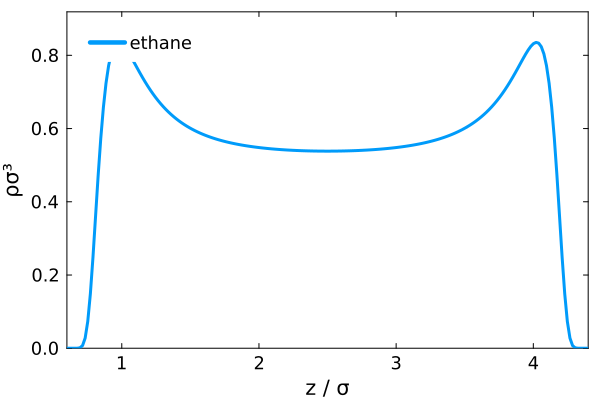

In [16]:
plot(system, ρ)

Note that this profile is just an initial guess and does not correspond to the true equilibrium profile. This profile must be solved for iteratively such that the following equation is satisfied:
$$ \rho(\mathbf{r}) = \rho^b \exp\left[-\beta\left(\frac{\delta F_\mathrm{res}}{\delta \rho(\mathbf{r})}+V_\mathrm{ext}(\mathbf{r})\right)\right]$$

This is achieved using the `converge!(system, ρ)` function:

In [17]:
converge!(system, ρ);

We can see the visual difference in the converged profile:

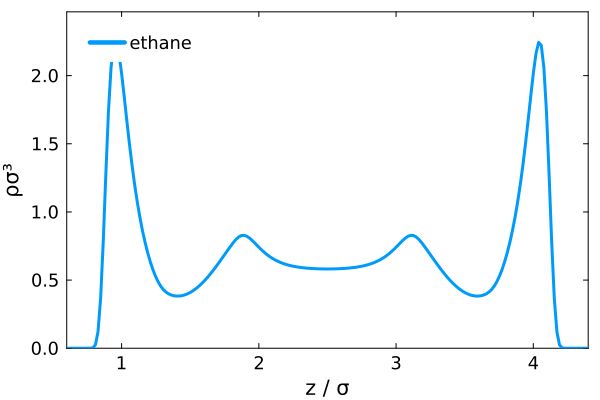

In [18]:
plot(system, ρ)